# Classical Grid Schemes Exploration

This notebook acts as the base for the comparison of the classical grids:

- Driscol-Healy
- McEwen-Wiaux
- Gauss-Legendre

This notebook uses functions from the `s2fft` library (Documentation at [s2fft Documentation](https://astro-informatics.github.io/s2fft/)) which sets-up the grid points, computes the harmonics, and allows fast algorithms for the forward and inverse SHT for the supported grids.

The goal of this notebook is to:
1. Generate a ground-truth signal with a set bandlimit of L.
2. Conduct the inverse SHT to get coefficients for undersampled, critical and oversampled grids.
3. Compute the reconstructed signal using the coefficients.
4. Compare and investigate errors.

In [ ]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec

import pandas as pd

import jax
jax.config.update("jax_enable_x64", True)

import s2fft
from s2fft.utils import signal_generator
from s2fft.sampling import s2_samples

from scipy.special import sph_harm_y

## Helper functions

In [ ]:
def zero_pad_coefficients(flm, L_from, L_to):
    """
    Used when the sampling grid has a higher bandlimit capacity than the actual bandlimit (oversampled grids)
    Sets the "added" coefficients to 0.
    """
    # Convert from 2D (l, m) coefficients to 1D
    flm_1d = s2_samples.flm_2d_to_1d(flm, L_from)
    # Create an array of zeros with size of no. of coeffs of the larger grid                      
    flm_1d_padded = np.zeros(s2_samples.ncoeff(L_to), dtype=flm.dtype)
    # Add back the original coefficients 
    flm_1d_padded[: s2_samples.ncoeff(L_from)] = flm_1d
    # Convert back from 1D to 2D
    flm_2d = s2_samples.flm_1d_to_2d(flm_1d_padded, L_to)            
    return flm_2d   

def get_grid(L, sampling):
    """
    Returns the sampling points for a given sampling scheme
    Reference: https://astro-informatics.github.io/s2fft/api/sampling/spherical_samples.html
    """
    thetas = s2_samples.thetas(L, sampling=sampling)
    phis = s2_samples.phis_equiang(L, sampling=sampling)
    return thetas, phis

def inverse_sht(flm, L_actual, L_grid, sampling):
    """
    Compute the inverse SHT. Returns function values at every point on the grid

    When L_grid >= L_actual: Use the provided s2fft function
    When L_grid < L_actual (undersampled):  Use direct synthesis
    """

    if L_grid >= L_actual:
        flm_padded = zero_pad_coefficients(flm, L_actual, L_grid)
        return s2fft.inverse(flm_padded, L_grid, sampling=sampling, method="numpy", reality=False)
        
    else:
        # Get points on the sampling grid
        thetas, phis = get_grid(L_grid, sampling)

        # Flatten the coefficients to 1D
        coeffs = s2_samples.flm_2d_to_1d(flm, L_actual)

        # Builds the array of l and m pairs.
        # E.g. for L_actual = 16
        # ls = [0,  1, 1, 1,  2, ..., 15, 15]
        # ms = [0, -1, 0, 1, -2, ..., 14, 15]
        ls = np.concatenate([np.full(2 * l + 1, l) for l in range(L_actual)])
        ms = np.concatenate([np.arange(-l, l + 1)  for l in range(L_actual)])

        # Create the theta-phi grid
        TH, PH = np.meshgrid(thetas, phis, indexing="ij")

        # Get the spherical harmonics for every theta-phi pair for each harmonic mode.
        Y = sph_harm_y(ls, ms, TH[..., None], PH[..., None])

        # Get the values of the function at every grid point
        return Y @ coeffs

def compute_relative_l2_error(a, b):
    """
    Returns the relative L2 error between two arrays.
    """
    return np.linalg.norm((a - b)) / np.linalg.norm(a)


def compute_error_per_degree(flm_true_p, flm_rec_p):
    """
    Computes the relative error per l in L
    """
    L_max = flm_true_p.shape[0]
    errors = np.zeros(L_max)
    for l in range(L_max):
        num = np.linalg.norm(flm_true_p[l] - flm_rec_p[l])
        den = np.linalg.norm(flm_true_p[l])
        errors[l] = num / den if den > 0 else num
    return errors

def compute_error_per_mode(flm_true_p, flm_rec_p):
    """
    Computes the absolute error for each coefficient mode (l, m)
    Returns with the 2D format with m out of l range set to NaN for plotting
    """
    L = flm_true_p.shape[0]
    # Start with an array full of NaN values
    errors = np.full(flm_true_p.shape, np.nan)
    # Go through each l value
    for l in range(L):
        # Go through each m value for this l
        for m in range(-l, l + 1):
            # Convert m to the correct column index
            col = m + (L - 1)
            # Compute the absolute error for this coefficient
            errors[l, col] = np.abs(flm_true_p[l, col] - flm_rec_p[l, col])
    return errors

## Generating Ground Truth Signal

To generate the ground truth signal, we use a random number generator combined with s2fft's signal_generator ([Link to documentation](https://astro-informatics.github.io/s2fft/api/utility/signal_generator.html))

We set the signal to be bandlimited to degree 15. 

Note: the degree fed to the signal generator returns coefficients up to degree (L-1). <br>
For example, L=16 returns coeffiencts from degree 0-15.

In [ ]:
L_actual = 16
seed = 42

rng = np.random.default_rng(seed)
flm_true = signal_generator.generate_flm(rng, L_actual, reality=False)
print("flm_true shape:", flm_true.shape, "dtype:", flm_true.dtype)

flm_true shape: (16, 31)  dtype: complex128


### Visualising the Signal

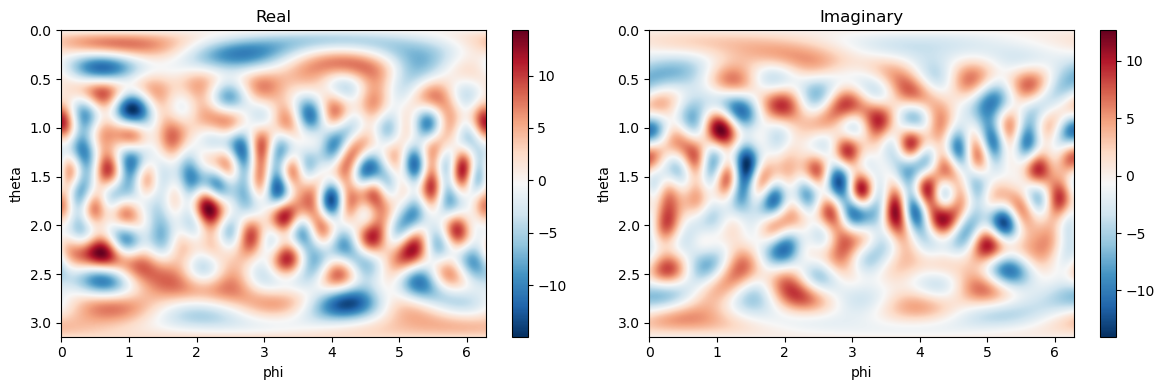

In [71]:
L_dense = 256
f_dense = inverse_sht(flm_true, L_actual, L_dense, 'dh')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title in zip(axes, [f_dense.real, f_dense.imag], ["Real", "Imaginary"]):
    im = ax.imshow(data, extent=[0, 2 * np.pi, np.pi, 0], aspect="auto", cmap="RdBu_r")
    ax.set_title(f"{title}")
    ax.set_xlabel("phi")
    ax.set_ylabel("theta")
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Grid Parameters

We set-up our grid evaluation cases as follows. For each of the 3 schemes (DH, GL and MW), we create cases for grids that are undersampled (lower bandlimit capacity), critically sampled (exact bandlimit capacity), and oversampled (greater bandlimit capacity).

In [72]:
L_grid_cases = [8, 12, 16, 24]
sampling_schemes = ['dh', 'gl', 'mw']
scheme_naming = {
    'dh' : 'Driscoll-Healy',
    'gl' : 'Gauss-Legendre',
    'mw' : 'McEwen-Wiaux'
}

## Visualising Grids

Plotting the grid points against theta and phi, results on the following:

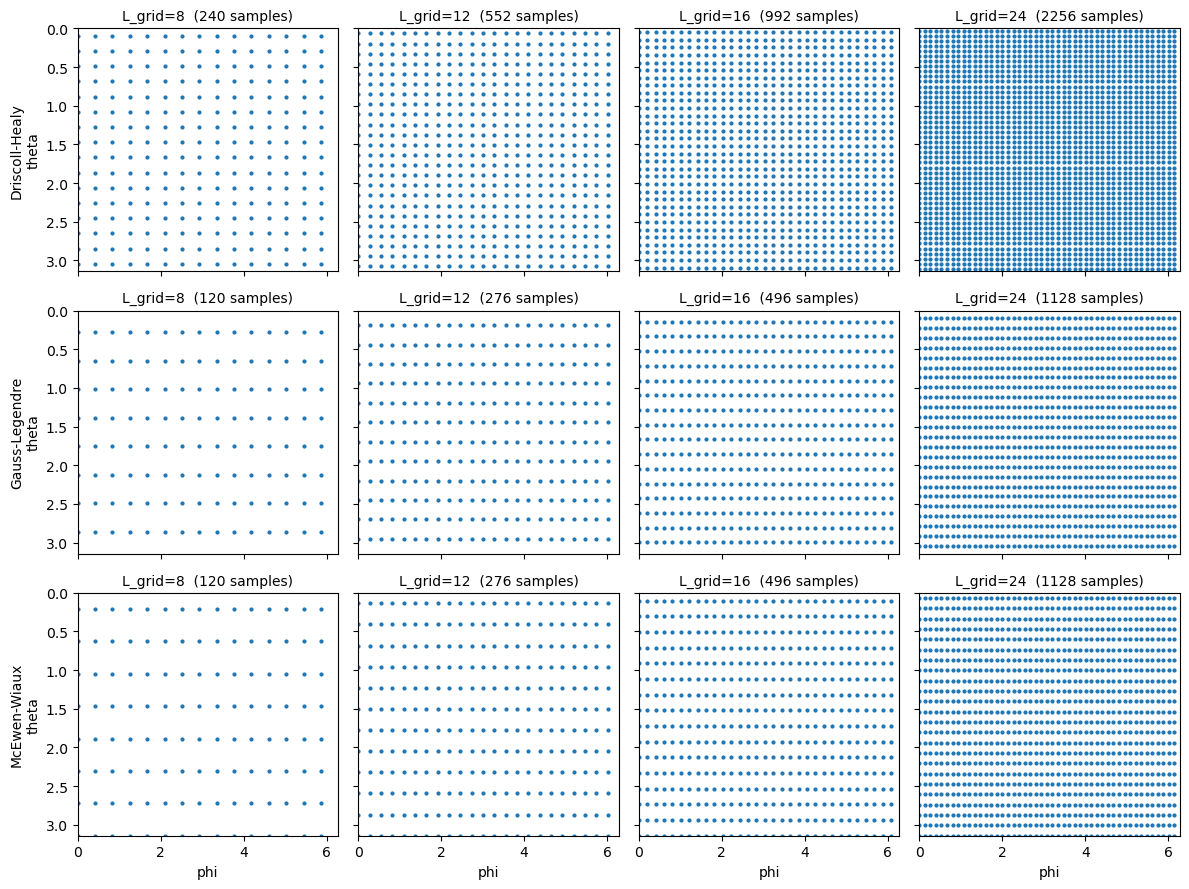

In [73]:
fig, axes = plt.subplots(
    len(sampling_schemes), len(L_grid_cases),
    figsize=(3 * len(L_grid_cases), 3 * len(sampling_schemes)),
    sharex=True, sharey=True,
)

for i, sampling in enumerate(sampling_schemes):
    for j, L_grid in enumerate(L_grid_cases):
        ax = axes[i, j]
        thetas, phis = get_grid(L_grid, sampling)
        TH, PH = np.meshgrid(thetas, phis, indexing="ij")
        ax.scatter(PH.ravel(), TH.ravel(), s=4)
        ax.set_xlim(0, 2 * np.pi)
        ax.set_ylim(np.pi, 0)

        n_samples = len(thetas) * len(phis)
        ax.set_title(f"L_grid={L_grid}  ({n_samples} samples)", fontsize=10)

        if i == len(sampling_schemes) - 1:
            ax.set_xlabel("phi")

    axes[i, 0].set_ylabel(f"{scheme_naming[sampling]}\ntheta", fontsize=10)

plt.tight_layout()
plt.show()

All 3 schemes have the same number of points on the azimuth for a given degree. GH and MW grids use half of the elevation points on the grid as compared to DH.

## Main Experiment Loop

<img src="images/cg_main_flow.png" width="1000">

This section covers the main experiment pipeline.

For every case in every sampling scheme, we:
1. Get the values of the ground-truth function on the sampling points.
2. Conduct the forward SHT to get the SHT coefficients.
3. Reconstruct the function based on the calculated coefficients.
4. Calculate the function and coefficient errors. 

In [ ]:
results = []

# Looping through sampling schemes and grid bandlimit cases:
for sampling in sampling_schemes:
    for L_grid in L_grid_cases:

        # Get the function values using the generated ground-truth coefficients on the points on the sampling grid
        f_true = inverse_sht(flm_true, L_actual, L_grid, sampling)
        
        # Get the SHT coefficients based on the function values and points on the sampling grid
        flm_recovered = s2fft.forward(f_true, L_grid, sampling=sampling, method="numpy", reality=False)

        # Reconstruct the function values based on the generated coefficients
        f_recon = s2fft.inverse(flm_recovered, L_grid, sampling=sampling, method="numpy", reality=False)

        # Get the error of the function values
        err_func = compute_relative_l2_error(f_true, f_recon)

        L_max = max(L_actual, L_grid)

        flm_true_p = zero_pad_coefficients(flm_true, L_actual, L_max)
        flm_recovered_p = zero_pad_coefficients(flm_recovered, L_grid, L_max)

        # Get the error of the coefficients.
        err_coeff = compute_relative_l2_error(flm_true_p, flm_recovered_p)
        per_deg = compute_error_per_degree(flm_true_p, flm_recovered_p)
        per_mode = compute_error_per_mode(flm_true_p, flm_recovered_p)

        n_elev = s2_samples.f_shape(L_grid, sampling)[0]
        n_azimuth = s2_samples.f_shape(L_grid, sampling)[1]

        results.append({
            "sampling_scheme" : scheme_naming[sampling],
            "L_grid" : L_grid,
            "n_elev" : n_elev,
            "n_azimuth" : n_azimuth,
            "n_samples": n_elev * n_azimuth,
            "err_func": err_func,
            "err_coeff": err_coeff,
            "per_degree": per_deg,
            "per_mode": per_mode
        })

## Results

Results are saved to a dataframe for further use.

In [86]:
df = pd.DataFrame(results)

In [85]:
df[['sampling_scheme', 'L_grid', 'err_func', 'err_coeff', 'per_degree', 'per_mode']]

,sampling_scheme,L_grid,err_func,err_coeff,per_degree,per_mode
0,Driscoll-Healy,8,8.052682e-01,9.844119e-01,"[7.170267539122736, 0.8727481610631099, 0.8089...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
1,Driscoll-Healy,12,6.783235e-01,7.411004e-01,"[2.140363173874441e-14, 4.7633863567023036e-15...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
2,Driscoll-Healy,16,3.876121e-15,3.329608e-15,"[2.2742599767736966e-15, 2.1442083740574198e-1...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
3,Driscoll-Healy,24,9.043907e-15,6.299602e-15,"[8.956436002738269e-15, 2.2383963746776384e-15...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
4,Gauss-Legendre,8,6.774680e-01,1.091567e+00,"[7.1701178235718475, 0.9366326601609554, 1.177...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
5,Gauss-Legendre,12,6.085390e-01,7.932023e-01,"[5.107360606386252e-14, 1.7491130874003305e-14...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
6,Gauss-Legendre,16,2.510701e-14,1.215980e-14,"[6.051906016409048e-15, 1.3109010039143206e-14...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
7,Gauss-Legendre,24,3.066124e-14,1.458145e-14,"[1.1842460930453908e-14, 7.096374704194103e-15...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
8,McEwen-Wiaux,8,5.216005e-01,1.134144e+00,"[13.374913275875606, 1.9701011909895854, 1.448...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."
9,McEwen-Wiaux,12,5.675148e-01,8.331361e-01,"[0.011464486028780953, 0.02529216403852791, 0....","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,..."


## Sampling Errors

Reconstruction quality per grid case is measured against the following:

**1. Function error**

We test on how close the reconstructed function values are compared to the original ground-truth function. We calculate the relative global reconstruction error via:

$$
\frac{
\left\| f_{\text{true}} - f_{\text{recon}} \right\|_F
}{
\left\| f_{\text{true}} \right\|_F
}
$$

where:

- $f_{\text{true}}$ is the original function evaluated on the sampling grid.
- $f_{\text{recon}}$ is the reconstructed function after applying the forward and inverse SHT.
- $\|\cdot\|_F$ is the Frobenius norm.

**2. Coefficient error**

Global coefficient error is computed similarly. Aside from this, we also compute the relative error per degree $l$ and the absolute error per mode $(l, m)$.

The following tables summarize the global errors:

In [93]:
(df.pivot(index='L_grid', columns='sampling_scheme', values='err_func')
   .style.format('{:.2e}')
   .set_caption('Global Function Error'))

sampling_scheme,Driscoll-Healy,Gauss-Legendre,McEwen-Wiaux
L_grid,,,
8,8.05e-01,6.77e-01,5.22e-01
12,6.78e-01,6.09e-01,5.68e-01
16,3.88e-15,2.51e-14,6.70e-15
24,9.04e-15,3.07e-14,7.97e-15


In [94]:
(df.pivot(index='L_grid', columns='sampling_scheme', values='err_coeff')
   .style.format('{:.2e}')
   .set_caption('Global Coefficient Error'))

sampling_scheme,Driscoll-Healy,Gauss-Legendre,McEwen-Wiaux
L_grid,,,
8,9.84e-01,1.09e+00,1.13e+00
12,7.41e-01,7.93e-01,8.33e-01
16,3.33e-15,1.22e-14,5.13e-15
24,6.30e-15,1.46e-14,5.86e-15


For all sampling schemes, **errors on the critical grid (exact bandlimit) and oversampled grid are numerically equivalent to 0**, for both the function and the coefficients. This shows accurate reconstruction for those grids. Below the critical grid, errors are higher which is expected due to undersampling.

## Visualising Absolute Error Per Mode

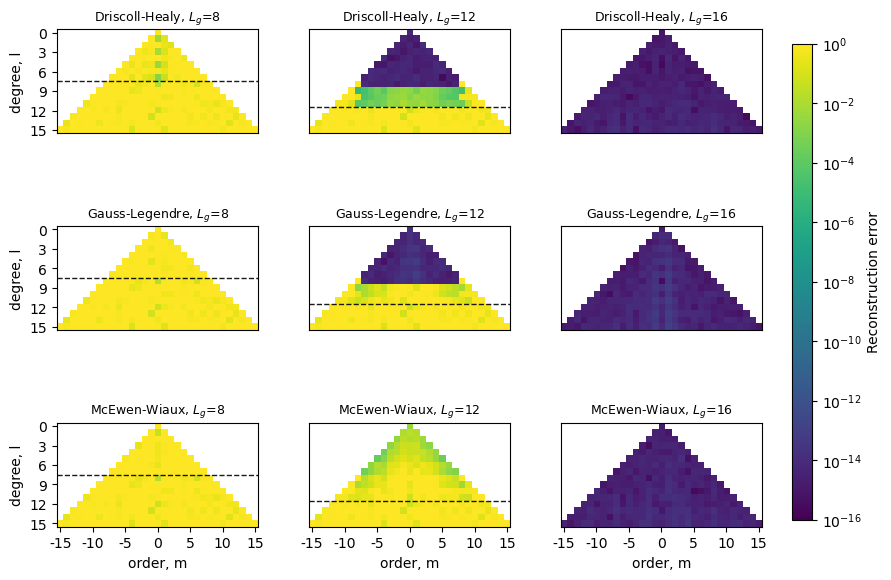

In [107]:
## Generating Plots

# Setting a static range for consistency
VMIN, VMAX = 1e-16, 1e0

schemes = ["Driscoll-Healy", "Gauss-Legendre", "McEwen-Wiaux"]
L_grids = [8, 12, 16]

fig, axes = plt.subplots(3, 3, figsize=(10, 7))

for row_i, scheme in enumerate(schemes):
    for col_j, L_grid in enumerate(L_grids):
        ax = axes[row_i, col_j]
        row = df[(df["sampling_scheme"] == scheme) & (df["L_grid"] == L_grid)].iloc[0]
        err_2d = row["per_mode"]
        err_plot = np.where(err_2d < VMIN, VMIN, err_2d)

        im = ax.imshow(
            err_plot, cmap="viridis", interpolation="nearest",
            norm=LogNorm(vmin=VMIN, vmax=VMAX),
        )
        ax.set_title(f"{scheme}, $L_g$={L_grid}", fontsize=9)

        im = ax.imshow(
            err_plot, cmap="viridis", interpolation="nearest",
            norm=LogNorm(vmin=VMIN, vmax=VMAX),
        )
        ax.set_title(f"{scheme}, $L_g$={L_grid}", fontsize=9)

        # Horizontal line on L_grid=8 and L_grid=12 panels
        if L_grid in [8, 12]:
            ax.axhline(y=L_grid - 0.5, color="black", linewidth=1.0, linestyle="--", alpha=0.9)

        L = err_2d.shape[0]
        if row_i == 2:
            xstep = max(1, (2 * L - 1) // 6)
            xt = np.arange(0, 2 * L - 1, xstep)
            ax.set_xticks(xt); ax.set_xticklabels(xt - (L - 1))
            ax.set_xlabel("order, m")
        else:
            ax.set_xticks([])

        if col_j == 0:
            ystep = max(1, L // 5)
            yt = np.arange(0, L, ystep)
            ax.set_yticks(yt); ax.set_yticklabels(yt)
            ax.set_ylabel(r"degree, l")
        else:
            ax.set_yticks([])

fig.subplots_adjust(right=0.83, hspace=0.35, wspace=0.25)
cbar_ax = fig.add_axes([0.86, 0.15, 0.02, 0.68])

cbar = fig.colorbar(
    ScalarMappable(norm=LogNorm(vmin=VMIN, vmax=VMAX), cmap="viridis"),
    cax=cbar_ax
)
cbar.set_label("Reconstruction error", fontsize=10)

plt.savefig("err_pyramid_grid.png", dpi=200, bbox_inches="tight")
plt.show()

The above plot shows the error per mode on the undersampled and critical grids. A cell coloured yellow has a large reconstruction error while a cell in purple is close to 0.

For the undersampled grid (L=8), we can see that for all 3 schemes, error is high on all degrees.

For the undersampled grid (L=12): 
- For the DH and GL schemes, error is close to 0 for the lower degree coefficients, the unrepresented coefficients (L > 12) are aliased on the higher degree coefficients and is shown by the error.
- For the MW scheme, error is spread across all coefficients regardless of degree.

The critical grid (L = L_actual) shows that we can reconstruct the bandlimited function accurately.

## Visualising Error per Degree

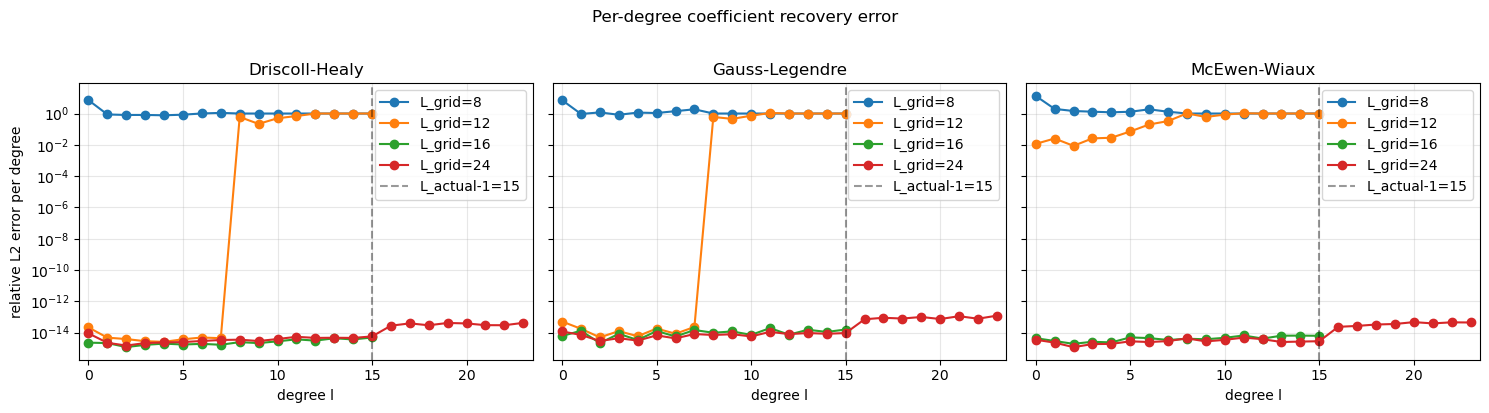

In [113]:
schemes = list(dict.fromkeys(r["sampling_scheme"] for r in results))
max_deg = max(len(r["per_degree"]) for r in results)

fig, axes = plt.subplots(1, len(schemes), figsize=(5 * len(schemes), 4), sharex=True, sharey=True)
if len(schemes) == 1:
    axes = [axes]

for ax, scheme in zip(axes, schemes):
    scheme_results = [r for r in results if r["sampling_scheme"] == scheme]
    for r in scheme_results:
        ax.semilogy(np.arange(len(r["per_degree"])), r["per_degree"], marker="o", label=f"L_grid={r['L_grid']}")
    ax.axvline(L_actual - 1, color="k", linestyle="--", alpha=0.4, label=f"L_actual-1={L_actual-1}")
    ax.set_xlim(-0.5, max_deg - 0.5)
    ax.set_title(scheme)
    ax.set_xlabel("degree l")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)

axes[0].set_ylabel("relative L2 error per degree")
fig.suptitle("Per-degree coefficient recovery error", y=1.02)
plt.tight_layout()
plt.show()

The above plots show the relative error per degree for each of the grid cases per scheme. This mostly drives a similar conclusion to the "Absolute Error per Mode" plot.

For the oversampled grids, we can see a slight increase in error but are still numerically equivalent to 0 and can be attributed to the additional calculations done.

## Reconstructed Function Visualisation

For the undersampled (L=12) and critically sampled cases:
1. We plot the reconstructed function to compare against the ground-truth.
2. We plot the function errors.

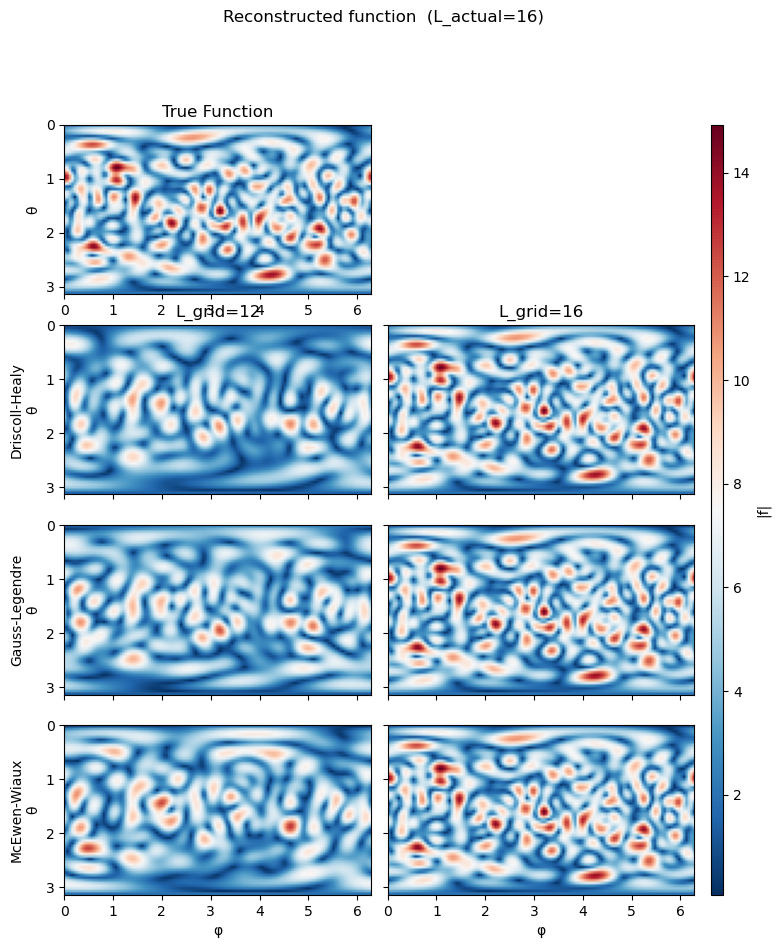

In [111]:
L_dense = 64
sampling_dense = "mw"
L_grids = [12, 16]

# --- Precompute ---
f_dense_true = inverse_sht(flm_true, L_actual, L_dense, sampling_dense)
sig_true = np.abs(f_dense_true)

f_dense_recons = {}
f_dense_errors = {}

for sampling in sampling_schemes:
    for L in L_grids:
        f_true_w  = inverse_sht(flm_true, L_actual, L, sampling)
        flm_rec_w = s2fft.forward(f_true_w, L, sampling=sampling, method="numpy", reality=False)
        f_dense_recon = s2fft.inverse(
            zero_pad_coefficients(flm_rec_w, L, L_dense),
            L_dense, sampling=sampling_dense, method="numpy", reality=False
        )
        f_dense_recons[(sampling, L)] = np.abs(f_dense_recon)
        f_dense_errors[(sampling, L)] = np.abs(f_dense_true - f_dense_recon)

# --- Colour limits ---
sig_vmin, sig_vmax = sig_true.min(), sig_true.max()
err_vmin = min(v.min() for v in f_dense_errors.values())
err_vmax = max(v.max() for v in f_dense_errors.values())

extent = [0, 2 * np.pi, np.pi, 0]
cmap = "RdBu_r"

def _plot_panel_grid(
    data_by_key, vmin, vmax, value_label, suptitle,
    shared_cbar=False, show_true=True,
):
    n_schemes = len(sampling_schemes)
    n_cols = len(L_grids)
    n_rows = (1 if show_true else 0) + n_schemes

    # Slightly shorter figure when the true row is dropped
    fig_h = 10 if show_true else 8
    fig = plt.figure(figsize=(8.5, fig_h))
    gs = GridSpec(
        n_rows, n_cols + 1,
        figure=fig,
        width_ratios=[1] * n_cols + [0.04],
        hspace=0.18, wspace=0.08,
    )

    # --- Optional True function panel ---
    im_true = None
    if show_true:
        true_vmin, true_vmax = (vmin, vmax) if shared_cbar else (sig_vmin, sig_vmax)
        ax_true = fig.add_subplot(gs[0, 0])
        im_true = ax_true.imshow(
            sig_true, extent=extent, aspect="auto",
            cmap=cmap, vmin=true_vmin, vmax=true_vmax,
        )
        ax_true.set_title("True Function")
        ax_true.set_ylabel("θ")

    # --- Data panels ---
    data_row_offset = 1 if show_true else 0
    data_axes = []
    im_data = None
    for row_i, sampling in enumerate(sampling_schemes):
        row = row_i + data_row_offset
        label = scheme_naming[sampling]
        for col, L in enumerate(L_grids):
            ax = fig.add_subplot(gs[row, col])
            if (row_i, col) != (0, 0):
                ax.sharex(data_axes[0])
                ax.sharey(data_axes[0])
            data_axes.append(ax)

            im_data = ax.imshow(
                data_by_key[(sampling, L)],
                extent=extent, aspect="auto",
                cmap=cmap, vmin=vmin, vmax=vmax,
            )
            if row_i == 0:
                ax.set_title(f"L_grid={L}")
            if col == 0:
                ax.set_ylabel(f"{label}\nθ")
            else:
                ax.tick_params(labelleft=False)
            if row_i == n_schemes - 1:
                ax.set_xlabel("φ")
            else:
                ax.tick_params(labelbottom=False)

    # --- Colorbar(s) ---
    if shared_cbar or not show_true:
        cax = fig.add_subplot(gs[:, -1])
        fig.colorbar(im_data, cax=cax, label=value_label)
    else:
        cax_true = fig.add_subplot(gs[0, -1])
        cax_data = fig.add_subplot(gs[1:, -1])
        fig.colorbar(im_true, cax=cax_true, label="|f_true|")
        fig.colorbar(im_data, cax=cax_data, label=value_label)

    fig.suptitle(suptitle, y=0.995)
    plt.show()


# Reconstructions: include true, single shared colorbar
_plot_panel_grid(
    f_dense_recons, sig_vmin, sig_vmax, "|f|",
    f"Reconstructed function  (L_actual={L_actual})",
    shared_cbar=True, show_true=True,
)

All critically sampled grids reconstructed the function accurately. For the undersampled grids, we can see the poor performance for the reconstruction.

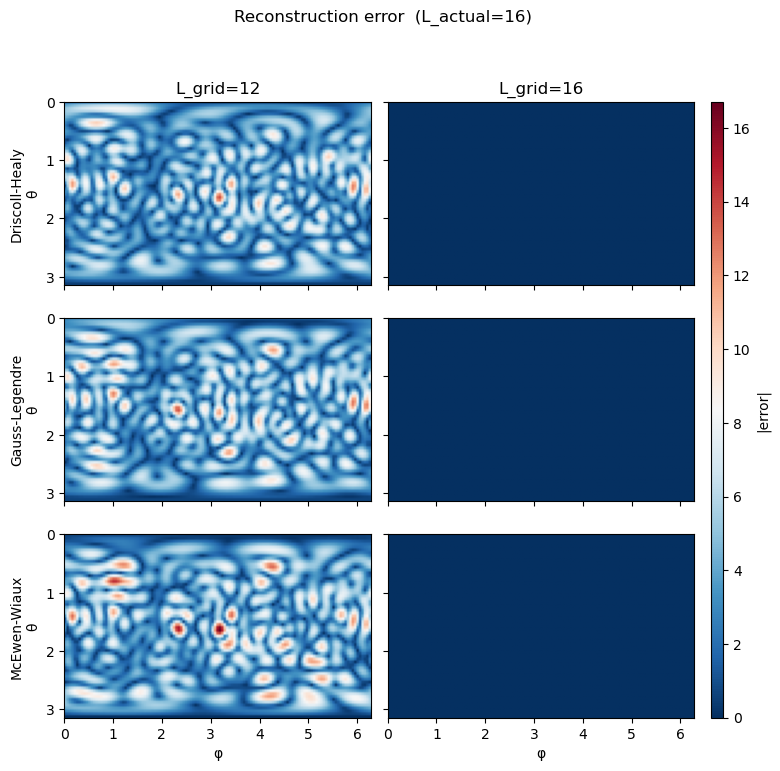

In [110]:
# Errors: drop true panel, single colorbar
_plot_panel_grid(
    f_dense_errors, err_vmin, err_vmax, "|error|",
    f"Reconstruction error  (L_actual={L_actual})",
    show_true=False,
)

All critically sampled grids have no reconstruction errors. For the undersampled grids, the error was spread through-out the grid.

## Summary

In this notebook, we conducted an investigation for undersampled, critically sampled and oversampled grids for the classical schemes (DH, GL and MW).

The critically sampled grids all reconstructed the ground-truth function to numerical precision. Therefore, using an oversampled grid will not provide additional performance improvements and will be wasting computational resources.

For next steps, some suggested investigations include:
1. Determining why the aliasing bleeds on all coefficients for the undersampled case of the McEwen-Wiaux grid.
2. If performance holds for grids with a large degree (L > 1000)